In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import load_sample_image


In [2]:
print( "Method 1: Using Scikit-learn Sample Image (china.jpg / flower.jpg) :")
print('='*68)

Method 1: Using Scikit-learn Sample Image (china.jpg / flower.jpg) :


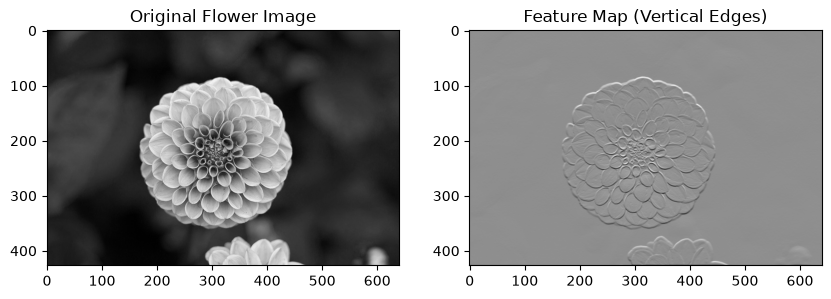

In [3]:

# Load and preprocess
flower = load_sample_image("flower.jpg") / 255
image = tf.image.rgb_to_grayscale(flower)
image = tf.cast(image, tf.float32)
image = tf.expand_dims(image, axis=0)

# Vertical edge kernel (Sobel)
vertical_edge_kernel = tf.constant([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
], dtype=tf.float32)

kernel = tf.reshape(vertical_edge_kernel, [3, 3, 1, 1])

# Convolution
feature_map = tf.nn.conv2d(image, kernel, strides=1, padding="SAME")

# Display
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image[0,:,:,0], cmap="gray")
plt.title("Original Flower Image")
plt.axis("on")

plt.subplot(1,2,2)
plt.imshow(feature_map[0,:,:,0], cmap="gray")
plt.title("Feature Map (Vertical Edges)")
plt.axis("on")

plt.show()

In [4]:
print("Method 2: Using Custom Downloaded JPG Image :")
print('='*46)

Method 2: Using Custom Downloaded JPG Image :


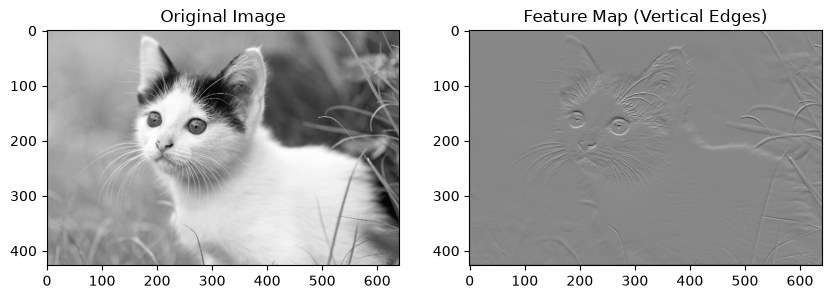

In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load your own image
image = tf.io.read_file("cat.jpg")
image = tf.image.decode_jpeg(image, channels=3)
image = tf.image.resize(image, (427, 640))
image = image / 255.0

# Convert to grayscale
image = tf.image.rgb_to_grayscale(image)
image = tf.cast(image, tf.float32)
image = tf.expand_dims(image, axis=0)

# Vertical edge kernel
vertical_edge_kernel = tf.constant([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
], dtype=tf.float32)

kernel = tf.reshape(vertical_edge_kernel, [3,3,1,1])

# Convolution
feature_map = tf.nn.conv2d(image, kernel, strides=1, padding="SAME")

# Display
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image[0,:,:,0], cmap="gray")
plt.title("Original Image")
plt.axis("on")

plt.subplot(1,2,2)
plt.imshow(feature_map[0,:,:,0], cmap="gray")
plt.title("Feature Map (Vertical Edges)")
plt.axis("on")

plt.show()

In [6]:
print("Convert Sample Image to 2D Feature Map using Conv2D :")
print('='*56)

Convert Sample Image to 2D Feature Map using Conv2D :


In [7]:
from sklearn.datasets import load_sample_image
import tensorflow as tf
from tensorflow import keras

# Load Sample Image
image = load_sample_image("china.jpg") / 255
# image = load_sample_image("flower.jpg") / 255

# Convert to Tensor
input_tensor = tf.convert_to_tensor(image, dtype=tf.float32)
input_tensor = tf.expand_dims(input_tensor, axis=0)

# Conv2D Layer
conv_layer = keras.layers.Conv2D(
    filters=32,
    kernel_size=3,
    padding='same',
    activation='relu'
)

# Apply Conv2D
output_tensor = conv_layer(input_tensor)

print("Input Shape:", input_tensor.shape)
print("Output Shape:", output_tensor.shape)

Input Shape: (1, 427, 640, 3)
Output Shape: (1, 427, 640, 32)


In [8]:
print("Convert Custom JPG Image to 2D Feature Map using - Conv2D:")
print('='*58)

Convert Custom JPG Image to 2D Feature Map using - Conv2D:


In [9]:
import tensorflow as tf
from tensorflow import keras

# Load Custom Image
image = tf.io.read_file("cat.jpg")   # Change to your image name
image = tf.image.decode_jpeg(image, channels=3)
image = tf.image.resize(image, (224, 224))
image = image / 255.0

# Convert to Tensor
input_tensor = tf.expand_dims(image, axis=0)

# Conv2D Layer
conv_layer = keras.layers.Conv2D(
    filters=32,
    kernel_size=3,
    padding='same',
    activation='relu'
)

# Apply Conv2D
output_tensor = conv_layer(input_tensor)

print("Input Shape:", input_tensor.shape)
print("Output Shape:", output_tensor.shape)

Input Shape: (1, 224, 224, 3)
Output Shape: (1, 224, 224, 32)


In [10]:
print("Apply MaxPooling2D on A Sample Image :")
print('='*38)

Apply MaxPooling2D on A Sample Image :


In [11]:
# Apply MaxPooling2D onA Sample Image

pool_layer = keras.layers.MaxPooling2D(pool_size=2)

pooled_output = pool_layer(output_tensor)

print("Shape before pooling:", output_tensor.shape)
print("Shape after pooling :", pooled_output.shape)

Shape before pooling: (1, 224, 224, 32)
Shape after pooling : (1, 112, 112, 32)


In [12]:
print("Apply MaxPooling2D on Custom JPG Image :")
print('='*41)

Apply MaxPooling2D on Custom JPG Image :


In [13]:
# Apply MaxPooling2D on Custom JPG Image

pool_layer = keras.layers.MaxPooling2D(pool_size=2)

pooled_output = pool_layer(output_tensor)

print("Shape before pooling:", output_tensor.shape)
print("Shape after pooling :", pooled_output.shape)

Shape before pooling: (1, 224, 224, 32)
Shape after pooling : (1, 112, 112, 32)


In [14]:
conv_layer = keras.layers.Conv2D(
    filters=32,
    kernel_size=3,
    strides=1,
    padding='same',
    activation='relu'
)
print(conv_layer)

<Conv2D name=conv2d_2, built=False>


In [15]:
print('='*115)

In [16]:
print("Building CNN - CIFAR-10 Dataset :")
print('='*33)

Building CNN - CIFAR-10 Dataset :


In [17]:
# Preprocess the CIFAR-10 Dataset

import tensorflow as tf
from tensorflow import keras

# Load CIFAR-10 Dataset
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Normalize Images
X_train = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# One-Hot Encode Labels
y_train = keras.utils.to_categorical(y_train_full, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# Display Dataset Shapes
print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)
print("Testing Images  :", X_test.shape)
print("Testing Labels  :", y_test.shape)

Training Images : (50000, 32, 32, 3)
Training Labels : (50000, 10)
Testing Images  : (10000, 32, 32, 3)
Testing Labels  : (10000, 10)


In [29]:
print("Display the First 10 Images from the CIFAR-10 Dataset:")
print('='*55)

Display the First 10 Images from the CIFAR-10 Dataset:


Training Images Shape: (50000, 32, 32, 3)
Training Labels Shape: (50000, 1)

First Image Shape: (32, 32, 3)
First Image Label: 6
Class Name: Frog


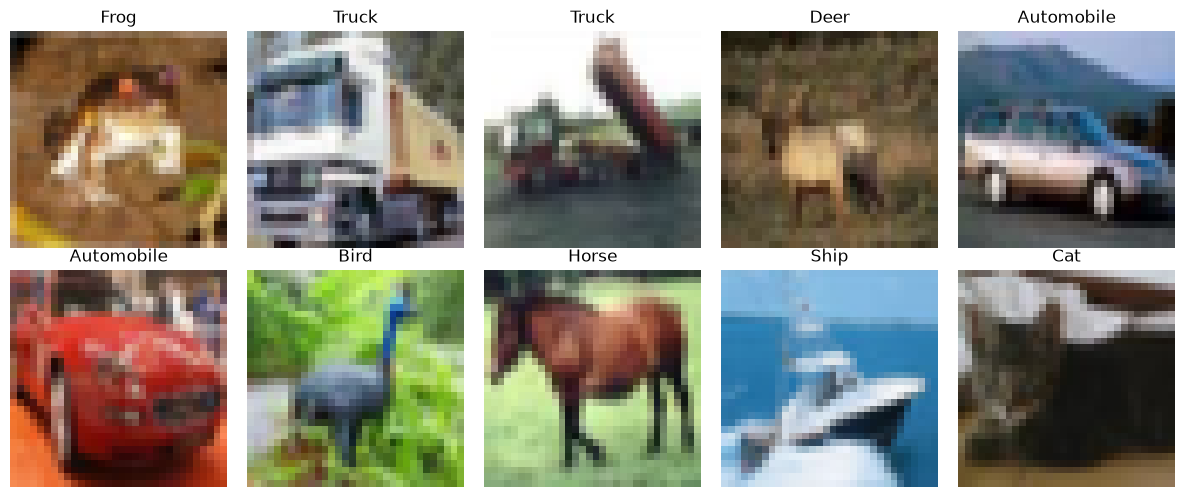

In [18]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Class names
class_names = [
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]

# Print dataset information
print("Training Images Shape:", X_train.shape)
print("Training Labels Shape:", y_train.shape)

print("\nFirst Image Shape:", X_train[0].shape)
print("First Image Label:", y_train[0][0])
print("Class Name:", class_names[int(y_train[0][0])])

# Display first 10 images
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[int(y_train[i][0])])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [27]:
print(" Build the CNN Model:")
print('='*23)

 Build the CNN Model:


In [19]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers



model = keras.Sequential([
    
    layers.Conv2D(filters=32, kernel_size=3, activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(pool_size=2),
    
    layers.Conv2D(filters=64, kernel_size=3, activation='relu'),
    layers.MaxPooling2D(pool_size=2),

    
    layers.Flatten(),
    
   
    layers.Dense(64, activation='relu'),
    
   
    layers.Dense(10, activation='softmax')
])


model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


model.summary()

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print(X_train.dtype)
print(X_test.dtype)

float32
float32


In [21]:
from tensorflow import keras

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

In [22]:
print("X_train:", X_train.shape, X_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)
print("X_test :", X_test.shape, X_test.dtype)
print("y_test :", y_test.shape, y_test.dtype)

X_train: (50000, 32, 32, 3) float32
y_train: (50000, 10) float64
X_test : (10000, 32, 32, 3) float32
y_test : (10000, 10) float64


In [24]:

print("Starting CNN training...")
history = model.fit(
    X_train, 
    y_train, 
    epochs=20, 
    batch_size=64,
    validation_data=(X_test, y_test)
)
print("Training finished.")


Starting CNN training...
Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.7846 - loss: 0.6147 - val_accuracy: 0.7126 - val_loss: 0.8813
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.7987 - loss: 0.5793 - val_accuracy: 0.7118 - val_loss: 0.8965
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.8084 - loss: 0.5475 - val_accuracy: 0.7023 - val_loss: 0.9432
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.8160 - loss: 0.5259 - val_accuracy: 0.6940 - val_loss: 1.0202
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.8270 - loss: 0.4976 - val_accuracy: 0.6938 - val_loss: 1.0204
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.8363 - loss: 0.4724 - val_accuracy: 0.6901 - val_loss: 1.0365
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.8452 - loss: 0.4445 - val_accuracy: 0.7012 - val_loss: 0.9989
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy:

In [30]:
print(" Analyze the curves:")
print('='*23)

 Analyze the curves:


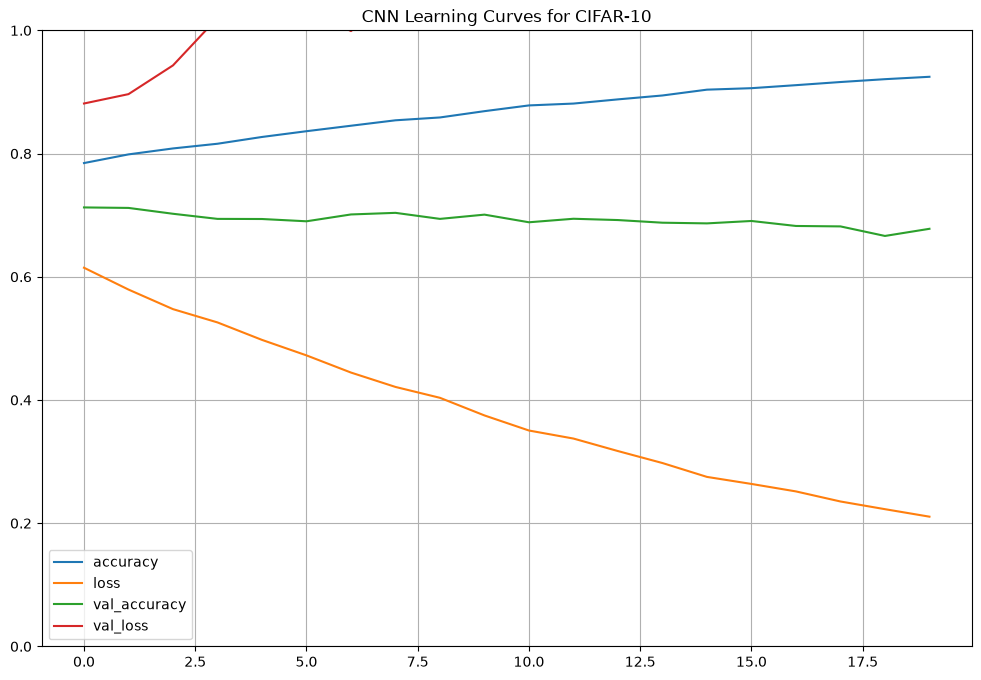

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history.history)
history_df.plot(figsize=(12, 8), grid=True, title="CNN Learning Curves for CIFAR-10", ylim=(0,1))
plt.show()


In [34]:
print("Evaluate the CNN performance:")
print('='*30)

Evaluate the CNN performance:


In [35]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get final loss and accuracy on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Final Test Accuracy: {accuracy * 100:.2f}%")

# Get predictions to generate detailed reports
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification Report
class_names = ['airplane', 
               'automobile', 
               'bird', 
               'cat', 
               'deer', 
               'dog',
               'frog',
               'horse', 
               'ship', 
               'truck']



print("\n--- Classification Report ---\n")

print(classification_report(y_true, y_pred, target_names=class_names))


Final Test Accuracy: 67.79%
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step

--- Classification Report ---

              precision    recall  f1-score   support

    airplane       0.74      0.68      0.71      1000
  automobile       0.76      0.81      0.78      1000
        bird       0.55      0.59      0.57      1000
         cat       0.49      0.48      0.49      1000
        deer       0.64      0.57      0.60      1000
         dog       0.58      0.62      0.60      1000
        frog       0.79      0.74      0.76      1000
       horse       0.71      0.74      0.73      1000
        ship       0.79      0.79      0.79      1000
       truck       0.74      0.77      0.75      1000

    accuracy                           0.68     10000
   macro avg       0.68      0.68      0.68     10000
weighted avg       0.68      0.68      0.68     10000

